<a href="https://colab.research.google.com/github/siddhantsawhney327/6thSem-ML-Lab/blob/main/1BM23CS327_LAB_9_KMEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Selected Features:
   petal_length  petal_width
0           1.4          0.2
1           1.4          0.2
2           1.3          0.2
3           1.5          0.2
4           1.4          0.2


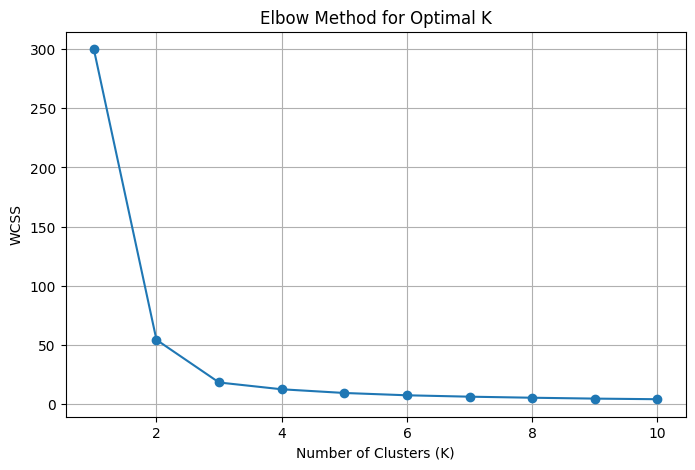

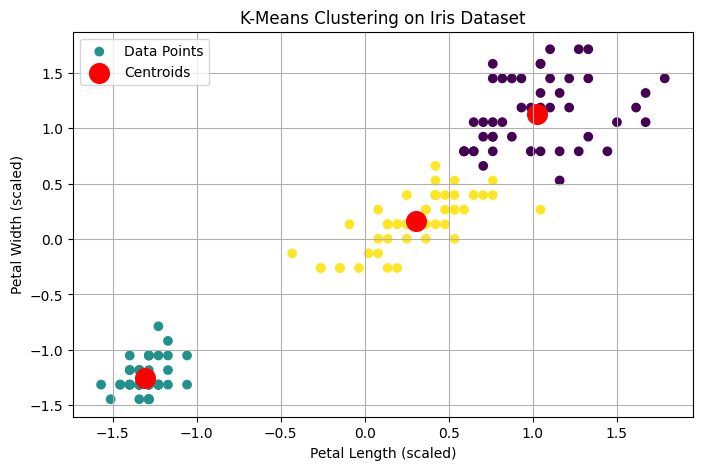

In [ ]:
# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ---------------- LOAD DATASET ----------------
df = pd.read_csv("iris.csv")

# Display first few rows
print("Dataset Preview:")
print(df.head())

# ---------------- FEATURE SELECTION ----------------
# Using only petal length and petal width
X = df[['petal_length', 'petal_width']]

print("\nSelected Features:")
print(X.head())

# ---------------- SCALING ----------------
# Scaling improves K-Means performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------- ELBOW METHOD ----------------
wcss = []   # Within Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# ---------------- APPLY K-MEANS ----------------
# From elbow plot, choose optimal K (usually 3 for iris)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# ---------------- VISUALIZE CLUSTERS ----------------
plt.figure(figsize=(8,5))

plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=y_kmeans, cmap='viridis', label='Data Points')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='red', label='Centroids')

plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.legend()
plt.grid(True)
plt.show()